# Esercizio 1 - Lezione 4
## Modello sequenziale per la regressione

### Caricamento dati

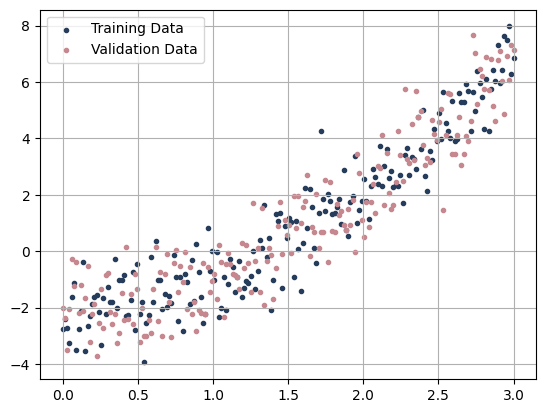

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat')

x_tr = data[:,0]
y_tr = data[:,1]
x_val = data[:,2]
y_val = data[:,3]

plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Modello lineare di baseline

In [3]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss=tf.keras.losses.MeanSquaredError)

history = model.fit(x_tr, y_tr, epochs=500,
          batch_size = x_tr.shape[0],
          validation_data = (x_val, y_val))

2026-03-23 11:09:03.859525: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-23 11:09:03.859676: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-23 11:09:03.859684: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-23 11:09:03.859729: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-23 11:09:03.859740: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 4.6380

2026-03-23 11:09:04.215785: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - loss: 4.6380 - val_loss: 4.6774
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 4.5878 - val_loss: 4.6333
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 4.5412 - val_loss: 4.5922
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.4978 - val_loss: 4.5537
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.4572 - val_loss: 4.5174
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.4189 - val_loss: 4.4831
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4.3826 - val_loss: 4.4504
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.3482 - val_loss: 4.4192
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.3153 - val_loss: 4.3892
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.2837 - val_loss: 4.3603
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.2533 - val_loss: 4.3324
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.2239 - val_loss: 4.3053


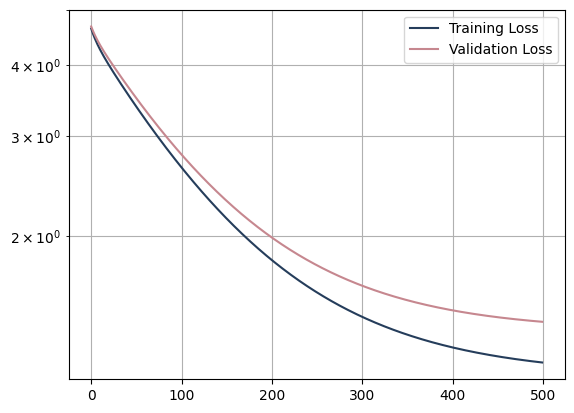

In [4]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


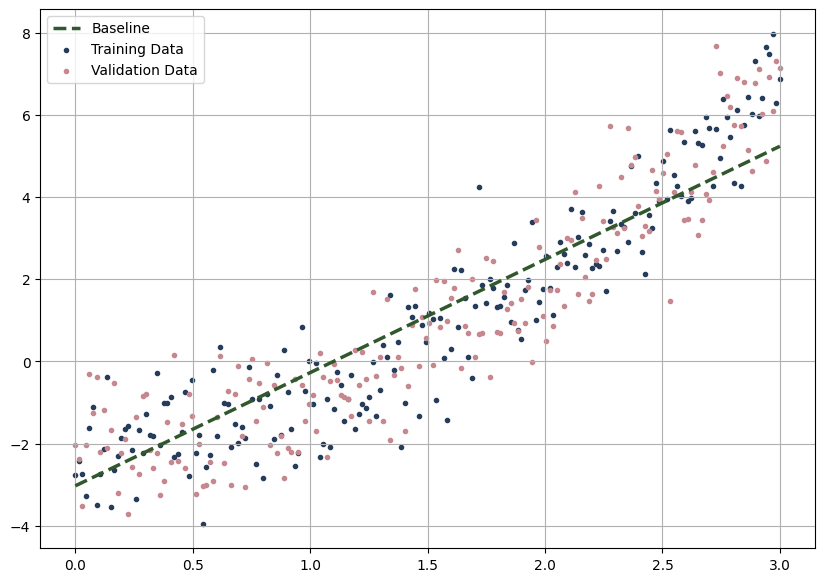

In [5]:
plt.figure(figsize=(10,7))
plt.plot(x_tr, model.predict(x_tr), '--',label='Baseline', color="#31572C", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Fully connected deep neural network con attivazione leaky-relu

In [6]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(1, activation='linear'))

model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss=tf.keras.losses.MSE)

history = model2.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=500, 
                     batch_size=x_tr.shape[0])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 10.4088 - val_loss: 9.8362
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.8853 - val_loss: 9.4286
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.4700 - val_loss: 9.1155
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 9.1504 - val_loss: 8.8237
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 8.8532 - val_loss: 8.5422
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8.5664 - val_loss: 8.2342
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.2522 - val_loss: 7.9405
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.9524 - val_loss: 7.6330
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.6375 - val_loss: 7.3442
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 7.3418 - val_loss: 7.0815
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.0719 - val_loss: 6.8196
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 6.8025 - val_

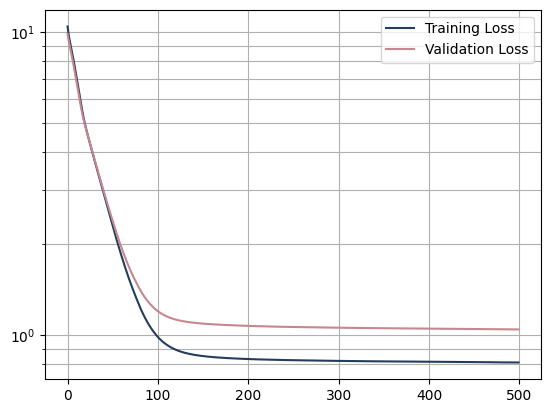

In [7]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


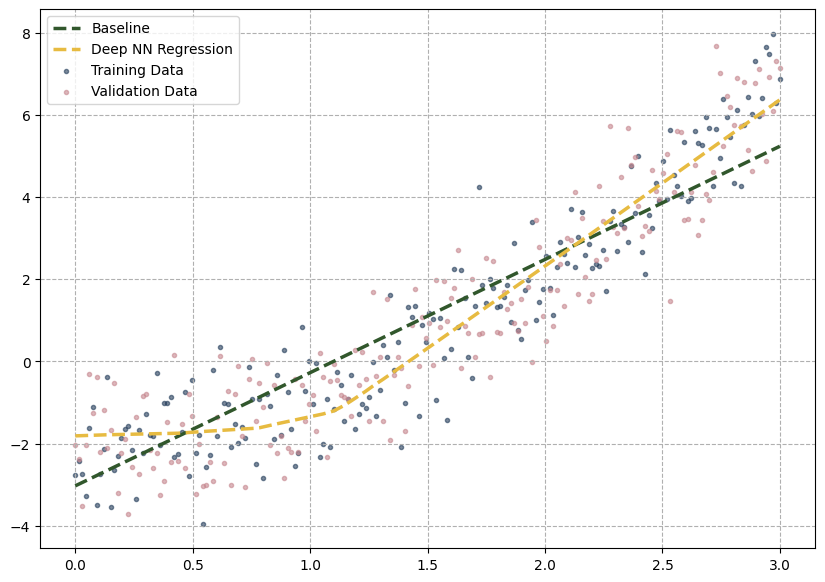

In [8]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model2.predict(x_val), '--', label='Deep NN Regression', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()

### Fully connected deep neural network con relu

In [28]:

model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Input(shape=(1,)))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(1))
model3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss="mean_squared_error")

history = model3.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=100, 
                     batch_size=x_tr.shape[0])

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 9.3914 - val_loss: 7.2839
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 7.2833 - val_loss: 6.6713
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 6.6552 - val_loss: 6.2369
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 6.2083 - val_loss: 5.8707
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 5.8302 - val_loss: 5.6622
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.6142 - val_loss: 5.4694
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.4140 - val_loss: 5.2923
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.2293 - val_loss: 5.1318
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.0612 - val_loss: 4.9653
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 4.8857 - val_loss: 4.8471
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4.7604 - val_loss: 4.7459
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4.6524 - val_l

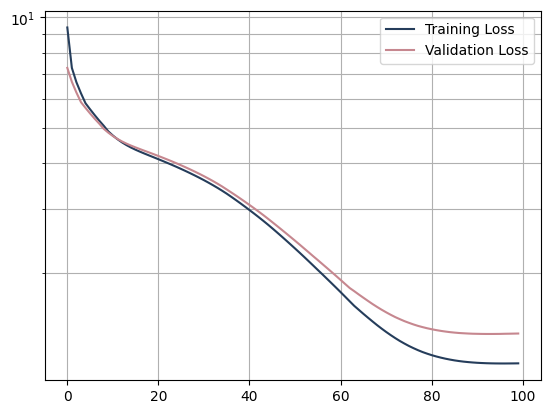

In [29]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


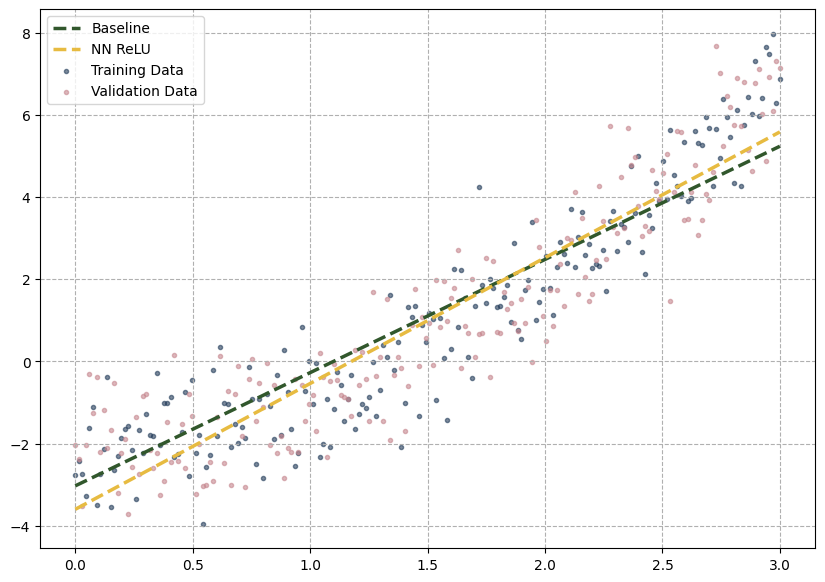

In [30]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model3.predict(x_val), '--', label='NN ReLU', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


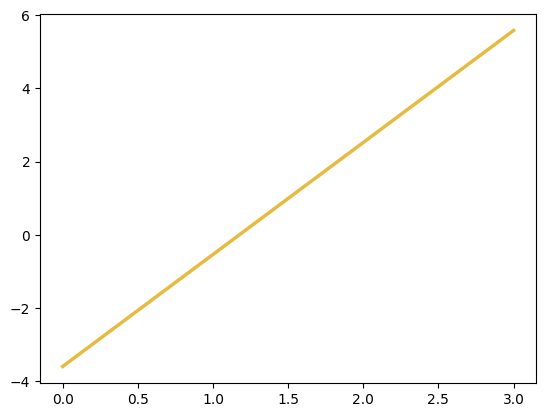

In [31]:
plt.plot(x_val, model3.predict(x_val), label='NN ReLU', color="#E7BB41", linewidth=2.5)
